# Lines, Derivatives, Gradients, and Optimization in Machine Learning

This notebook develops a geometric and computational understanding of:

1. A line as a **prediction function**
2. A line as a **decision boundary**
3. A linear classifier as a **projection onto a direction**
4. Derivatives and tangent lines
5. Partial derivatives and gradients
6. Directional derivatives and level curves
7. Gradients with respect to inputs and parameters
8. Gradient descent
9. The chain rule, Jacobians, and Hessians

The notebook includes short classroom activities throughout.

---

## Learning objectives

By the end of this notebook, you should be able to:

- distinguish between a regression line and a classification boundary;
- interpret the weight vector as a normal vector and as a gradient;
- explain why rotating coordinates can reduce a linear classifier to a one-dimensional threshold;
- compute derivatives, partial derivatives, gradients, Jacobians, and simple Hessians;
- connect the gradient to local change and optimization;
- implement gradient descent for a simple linear regression problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

# Part 1 — Three interpretations of a line

## 1.1 A line as a prediction function

In simple linear regression,

$$
\hat y = wx+b
$$

the horizontal coordinate is the input $x$, while the vertical coordinate is the target $y$.

For each input $x_i$, the line gives a prediction $\hat y_i$. The residual is

$$
e_i = y_i-\hat y_i.
$$

The residual is normally visualized as a **vertical difference** between an observation and the regression line.

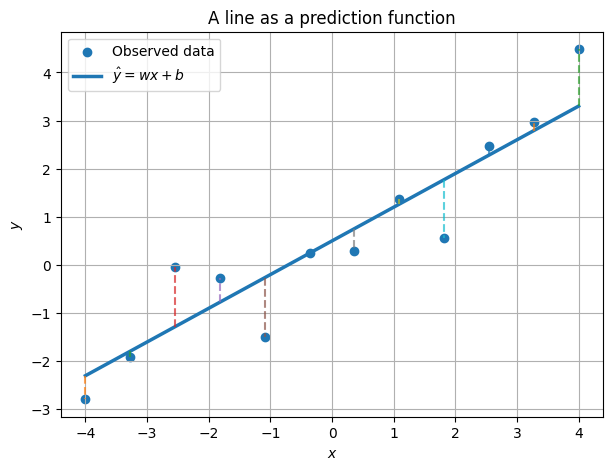

In [2]:
rng = np.random.default_rng(4)

x = np.linspace(-4, 4, 12)
w_true = 0.7
b_true = 0.5
y = w_true * x + b_true + rng.normal(0, 0.75, size=len(x))
y_hat = w_true * x + b_true

plt.scatter(x, y, label="Observed data")
plt.plot(x, y_hat, linewidth=2.5, label=r"$\hat y = wx+b$")

for xi, yi, yhi in zip(x, y, y_hat):
    plt.plot([xi, xi], [yhi, yi], linestyle="--", alpha=0.7)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("A line as a prediction function")
plt.legend()
plt.show()

### Activity 1 — Read the regression plot

Without running additional code, answer:

1. What does the vertical axis represent?
2. What is the meaning of a vertical dashed segment?
3. Is the line dividing the plane into positive and negative classes?
4. For the point with the largest residual, is the model overpredicting or underpredicting?

<details>
<summary><strong>Suggested answers</strong></summary>

1. The observed or predicted target value.
2. The residual \(y_i-\hat y_i\).
3. No. In this view, the line is the graph of a prediction function.
4. Inspect whether the observation lies above or below the line. Above means underprediction; below means overprediction.

</details>

## 1.2 A line as a decision boundary

For two input features,

$$
s(\mathbf{x}) = w_1x_1+w_2x_2+b
$$

is a scalar score. The decision boundary is the set of points satisfying

$$
w_1x_1+w_2x_2+b=0.
$$

The two sides of the line are:

$$
s(\mathbf{x})>0
\qquad\text{and}\qquad
s(\mathbf{x})<0.
$$

The vector

$$
\mathbf{w}=
\begin{bmatrix}
w_1\\
w_2
\end{bmatrix}
$$

is perpendicular to the boundary.

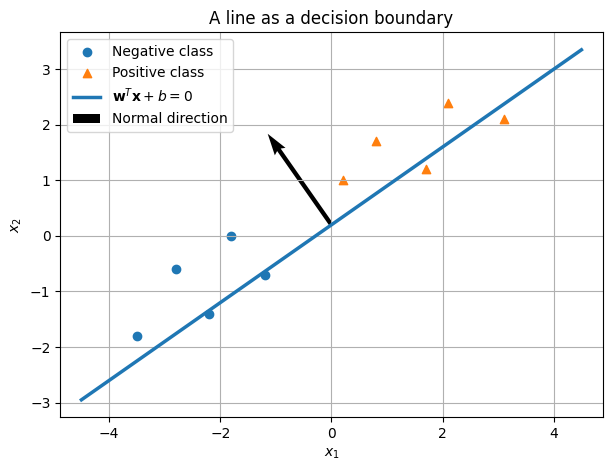

In [3]:
# A two-dimensional binary classification example
X_neg = np.array([
    [-3.5, -1.8],
    [-2.8, -0.6],
    [-2.2, -1.4],
    [-1.8,  0.0],
    [-1.2, -0.7],
])

X_pos = np.array([
    [0.2, 1.0],
    [0.8, 1.7],
    [1.7, 1.2],
    [2.1, 2.4],
    [3.1, 2.1],
])

w = np.array([-0.7, 1.0])
b = -0.2

x1 = np.linspace(-4.5, 4.5, 200)
x2_boundary = -(w[0] * x1 + b) / w[1]

plt.scatter(X_neg[:, 0], X_neg[:, 1], marker="o", label="Negative class")
plt.scatter(X_pos[:, 0], X_pos[:, 1], marker="^", label="Positive class")
plt.plot(x1, x2_boundary, linewidth=2.5, label=r"$\mathbf{w}^T\mathbf{x}+b=0$")

# Draw the normal vector from a point on the boundary
x0 = np.array([0.0, -b / w[1]])
w_unit = w / np.linalg.norm(w)
plt.quiver(
    x0[0], x0[1],
    w_unit[0], w_unit[1],
    angles="xy", scale_units="xy", scale=0.5,
    width=0.008,
    label="Normal direction"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("A line as a decision boundary")
plt.axis("equal")
plt.legend()
plt.show()

The signed perpendicular distance from a point $\mathbf{x}$ to the boundary is

$$
d(\mathbf{x})=
\frac{\mathbf{w}^{T}\mathbf{x}+b}
{\|\mathbf{w}\|}.
$$

Therefore, the score $\mathbf{w}^{T}\mathbf{x}+b$ is proportional to signed distance.

In [5]:
def score(X, w, b):
    return X @ w + b

def signed_distance(X, w, b):
    return score(X, w, b) / np.linalg.norm(w)

all_points = np.vstack([X_neg, X_pos])
scores = score(all_points, w, b)
distances = signed_distance(all_points, w, b)

print("Scores:")
print(scores)
print("\nSigned distances:")
print(distances)

Scores:
[ 0.45  1.16 -0.06  1.06 -0.06  0.66  0.94 -0.19  0.73 -0.27]

Signed distances:
[ 0.369  0.95  -0.049  0.868 -0.049  0.541  0.77  -0.156  0.598 -0.221]


### Activity 2 — Scores and classes

1. Compute the score of the point $\mathbf{x}=(2,1)$.
2. Is the point on the positive or negative side?
3. What happens to the decision boundary if $\mathbf{w}$ and $b$ are both multiplied by $10$?
4. What happens to the raw score?
5. What happens to the signed distance?

<details>
<summary><strong>Suggested answers</strong></summary>

For $\mathbf{w}=(-0.7,1)$ and $b=-0.2$,

$$
s(2,1)=-0.7(2)+1-0.2=-0.6.
$$

The point is on the negative side.

Multiplying both $\mathbf{w}$ and $b$ by $10$ does not change the zero-score boundary. The raw score is multiplied by $10$, but the signed distance remains unchanged because the denominator $\|\mathbf{w}\|$ is also multiplied by $10$.

</details>

## 1.3 Rotating coordinates

The classifier

$$
s(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b
$$

can be interpreted as:

1. project $\mathbf{x}$ onto the direction of $\mathbf{w}$;
2. add $b$;
3. compare the result with zero.

Define the unit vector

$$
\mathbf{u}_1=\frac{\mathbf{w}}{\|\mathbf{w}\|}.
$$

Choose a second unit vector $\mathbf{u}_2$ perpendicular to $\mathbf{u}_1$. Then define rotated coordinates:

$$
z_1=\mathbf{u}_1^{T}\mathbf{x},
\qquad
z_2=\mathbf{u}_2^{T}\mathbf{x}.
$$

The decision only depends on $z_1$, not $z_2$.

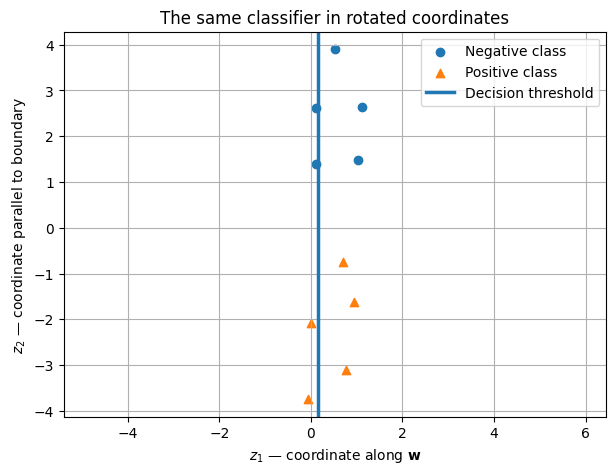

Orthonormal basis Q:
[[-0.573 -0.819]
 [ 0.819 -0.573]]

Q^T Q:
[[ 1. -0.]
 [-0.  1.]]

Threshold on z1: 0.1638463841038081


In [6]:
u1 = w / np.linalg.norm(w)
u2 = np.array([-u1[1], u1[0]])

Q = np.column_stack([u1, u2])  # columns form an orthonormal basis

X_all = np.vstack([X_neg, X_pos])
Z_all = X_all @ Q
Z_neg = Z_all[:len(X_neg)]
Z_pos = Z_all[len(X_neg):]

threshold = -b / np.linalg.norm(w)

plt.scatter(Z_neg[:, 0], Z_neg[:, 1], marker="o", label="Negative class")
plt.scatter(Z_pos[:, 0], Z_pos[:, 1], marker="^", label="Positive class")
plt.axvline(threshold, linewidth=2.5, label="Decision threshold")

plt.xlabel(r"$z_1$ — coordinate along $\mathbf{w}$")
plt.ylabel(r"$z_2$ — coordinate parallel to boundary")
plt.title("The same classifier in rotated coordinates")
plt.axis("equal")
plt.legend()
plt.show()

print("Orthonormal basis Q:")
print(Q)
print("\nQ^T Q:")
print(Q.T @ Q)
print("\nThreshold on z1:", threshold)

### Activity 3 — What changed after rotation?

Decide whether each statement is true or false.

1. The classifier changed.
2. The data points changed geometrically.
3. The coordinate descriptions changed.
4. The diagonal boundary became axis-aligned.
5. Classification became a one-dimensional threshold problem.
6. The coordinate \(z_2\) affects the prediction.

<details>
<summary><strong>Suggested answers</strong></summary>

1. False.
2. False.
3. True.
4. True.
5. True.
6. False.

</details>

# Part 2 — Derivatives

## 2.1 The derivative as local change

For a scalar function \(f:\mathbb{R}\rightarrow\mathbb{R}\),

$$
f'(x)=\lim_{h\rightarrow0}
\frac{f(x+h)-f(x)}{h}.
$$

The derivative is:

- the slope of the tangent line;
- the local rate of change;
- the coefficient in the best local linear approximation.

For a small change $\Delta x$,

$$
f(x+\Delta x)
\approx
f(x)+f'(x)\Delta x.
$$

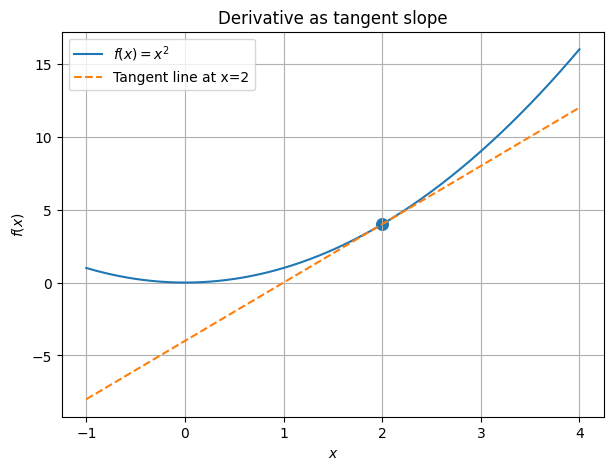

In [7]:
def f(x):
    return x**2

def df(x):
    return 2*x

x0 = 2.0
x_grid = np.linspace(-1, 4, 300)
tangent = f(x0) + df(x0) * (x_grid - x0)

plt.plot(x_grid, f(x_grid), label=r"$f(x)=x^2$")
plt.plot(x_grid, tangent, linestyle="--", label="Tangent line at x=2")
plt.scatter([x0], [f(x0)], s=70)
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("Derivative as tangent slope")
plt.legend()
plt.show()

In [8]:
# Numerical derivative using the difference quotient
def numerical_derivative(f, x, h):
    return (f(x + h) - f(x)) / h

for h in [1, 0.5, 0.1, 0.01, 0.001]:
    estimate = numerical_derivative(f, x0, h)
    print(f"h={h:<6} estimate={estimate:.6f}")

print("Exact derivative:", df(x0))

h=1      estimate=5.000000
h=0.5    estimate=4.500000
h=0.1    estimate=4.100000
h=0.01   estimate=4.010000
h=0.001  estimate=4.001000
Exact derivative: 4.0


### Activity 4 — Local linear approximation

For $f(x)=x^2$, estimate $f(2.05)$ using the tangent line at $x=2$.

Then compare the approximation with the exact value.

<details>
<summary><strong>Suggested solution</strong></summary>

$$
f(2)=4,\qquad f'(2)=4,\qquad \Delta x=0.05.
$$

Therefore,

$$
f(2.05)\approx 4+4(0.05)=4.2.
$$

The exact value is

$$
2.05^2=4.2025.
$$

</details>

In [ ]:
# Complete this cell
x0 = 2.0
delta_x = 0.05

approximation = None  # replace
exact = None          # replace

print("Approximation:", approximation)
print("Exact:", exact)

# Part 3 — Partial derivatives and gradients

## 3.1 Vector input, scalar output

Consider

$$
f(x_1,x_2)=x_1^2+2x_2^2.
$$

A partial derivative changes one coordinate while holding the other fixed:

$$
\frac{\partial f}{\partial x_1}=2x_1,
\qquad
\frac{\partial f}{\partial x_2}=4x_2.
$$

The gradient collects these partial derivatives:

$$
\nabla f(x_1,x_2)=
\begin{bmatrix}
2x_1\\
4x_2
\end{bmatrix}.
$$

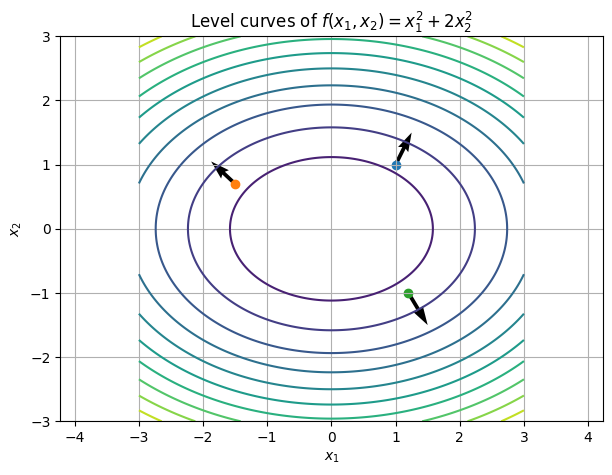

In [9]:
def f2(x1, x2):
    return x1**2 + 2*x2**2

def grad_f2(x1, x2):
    return np.array([2*x1, 4*x2])

x1_grid = np.linspace(-3, 3, 200)
x2_grid = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
F = f2(X1, X2)

plt.contour(X1, X2, F, levels=12)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title(r"Level curves of $f(x_1,x_2)=x_1^2+2x_2^2$")

sample_points = np.array([
    [1.0, 1.0],
    [-1.5, 0.7],
    [1.2, -1.0],
])

for point in sample_points:
    g = grad_f2(*point)
    plt.quiver(
        point[0], point[1],
        g[0], g[1],
        angles="xy", scale_units="xy", scale=8,
        width=0.007
    )
    plt.scatter(*point)

plt.axis("equal")
plt.show()

The gradient has three important interpretations:

1. It points in the direction of greatest local increase.
2. Its magnitude indicates how quickly the function increases.
3. It is perpendicular to the level curve \(f(\mathbf{x})=c\).

The multivariable local approximation is

$$
f(\mathbf{x}+\Delta\mathbf{x})
\approx
f(\mathbf{x})
+
\nabla f(\mathbf{x})^{T}\Delta\mathbf{x}.
$$

### Activity 5 — Compute and interpret a gradient

For

$$
f(x_1,x_2)=x_1^2+2x_2^2,
$$

at the point $(1,2)$:

1. Compute $\nabla f(1,2)$.
2. Which coordinate produces the larger local change?
3. Is the gradient tangent or perpendicular to the level curve?
4. What direction would produce the fastest decrease?

<details>
<summary><strong>Suggested answers</strong></summary>

\[
\nabla f(1,2)=
\begin{bmatrix}
2\\
8
\end{bmatrix}.
\]

The second coordinate has the larger partial derivative. The gradient is perpendicular to the level curve. The direction of fastest decrease is

\[
-\nabla f(1,2)=(-2,-8).
\]

</details>

## 3.2 Directional derivatives

For a unit direction $\mathbf{u}$, the directional derivative is

$$
D_{\mathbf{u}}f(\mathbf{x})
=
\nabla f(\mathbf{x})^{T}\mathbf{u}.
$$

Since this is a dot product,

$$
D_{\mathbf{u}}f
=
\|\nabla f\|\cos\theta.
$$

The largest value occurs when $\mathbf{u}$ points in the same direction as the gradient.

In [10]:
point = np.array([1.0, 2.0])
gradient = grad_f2(*point)

directions = {
    "x1 direction": np.array([1.0, 0.0]),
    "x2 direction": np.array([0.0, 1.0]),
    "diagonal direction": np.array([1.0, 1.0]) / np.sqrt(2),
    "negative gradient direction": -gradient / np.linalg.norm(gradient),
}

for name, u in directions.items():
    directional_derivative = gradient @ u
    print(f"{name:28s}: {directional_derivative: .4f}")

x1 direction                :  2.0000
x2 direction                :  8.0000
diagonal direction          :  7.0711
negative gradient direction : -8.2462


### Activity 6 — Find a direction with zero local change

At $(1,2)$, find a unit vector $\mathbf{u}$ such that

$$
\nabla f(1,2)^T\mathbf{u}=0.
$$

What is the geometric meaning of this direction?

<details>
<summary><strong>Suggested solution</strong></summary>

The gradient is $(2,8)$. Any perpendicular vector works, such as $(8,-2)$. Normalizing:

$$
\mathbf{u}
=
\frac{1}{\sqrt{68}}
\begin{bmatrix}
8\\
-2
\end{bmatrix}.
$$

This direction is tangent to the level curve, so the first-order change in $f$ is zero.

</details>

# Part 4 — The gradient and linear classifiers

Consider the linear score

$$
s(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b.
$$

The gradient with respect to the input is

$$
\nabla_{\mathbf{x}}s(\mathbf{x})=\mathbf{w}.
$$

Therefore:

- $\mathbf{w}$ points in the direction of greatest score increase;
- $\mathbf{w}$ is perpendicular to every level set;
- the decision boundary $s(\mathbf{x})=0$ is one level set.

This is why the weight vector is the normal vector to the decision boundary.

In [11]:
def linear_score(x, w, b):
    return w @ x + b

x_point = np.array([1.0, 1.0])
epsilon = 0.1

directions = {
    "along w": w / np.linalg.norm(w),
    "opposite w": -w / np.linalg.norm(w),
    "parallel to boundary": np.array([-w[1], w[0]]) / np.linalg.norm(w),
}

base_score = linear_score(x_point, w, b)
print("Base score:", base_score)

for name, u in directions.items():
    new_score = linear_score(x_point + epsilon*u, w, b)
    print(f"{name:22s}: score change = {new_score - base_score:+.6f}")

Base score: 0.10000000000000003
along w               : score change = +0.122066
opposite w            : score change = -0.122066
parallel to boundary  : score change = +0.000000


### Activity 7 — Explain the experiment

Why is the score change approximately zero when moving parallel to the boundary?

Your explanation should use both:

1. geometric language;
2. the directional derivative formula.

<details>
<summary><strong>Suggested answer</strong></summary>

Geometrically, moving parallel to a level set does not cross toward higher or lower score values.

Analytically,

\[
D_{\mathbf{u}}s
=
\nabla s^T\mathbf{u}
=
\mathbf{w}^T\mathbf{u}.
\]

A direction parallel to the boundary is perpendicular to \(\mathbf{w}\), so the dot product is zero.

</details>

# Part 5 — Derivatives with respect to model parameters

For the model

$$
\hat y=\mathbf{w}^{T}\mathbf{x}+b,
$$

there are two different gradients.

## With respect to the input

$$
\nabla_{\mathbf{x}}\hat y=\mathbf{w}.
$$

This measures sensitivity to the features.

## With respect to the weights

$$
\nabla_{\mathbf{w}}\hat y=\mathbf{x}.
$$

This measures sensitivity to the parameters.

Also,

$$
\frac{\partial \hat y}{\partial b}=1.
$$

### Activity 8 — Input gradient or parameter gradient?

For each question, identify the required derivative.

1. How does the prediction change if the customer's income changes?
2. How does the prediction change if \(w_2\) changes?
3. Which feature direction most increases the classifier score?
4. Which parameter should be adjusted to reduce the loss?

<details>
<summary><strong>Suggested answers</strong></summary>

1. Gradient with respect to the input.
2. Gradient with respect to the parameters.
3. Gradient with respect to the input.
4. Gradient of the loss with respect to the parameters.

</details>

# Part 6 — The loss gradient

For one observation, define

$$
\hat y=\mathbf{w}^{T}\mathbf{x}+b
$$

and the squared-error loss

$$
L(\mathbf{w},b)
=
\frac{1}{2}(\hat y-y)^2.
$$

Let

$$
e=\hat y-y.
$$

Using the chain rule,

$$
\nabla_{\mathbf{w}}L=e\mathbf{x},
\qquad
\frac{\partial L}{\partial b}=e.
$$

For an individual weight,

$$
\frac{\partial L}{\partial w_j}=ex_j.
$$

In [ ]:
x_example = np.array([2.0, -1.0])
w_example = np.array([0.5, 1.5])
b_example = 0.2
y_example = 1.0

y_hat_example = w_example @ x_example + b_example
error_example = y_hat_example - y_example
grad_w = error_example * x_example
grad_b = error_example

print("Prediction:", y_hat_example)
print("Error:", error_example)
print("Gradient with respect to w:", grad_w)
print("Derivative with respect to b:", grad_b)

### Activity 9 — Interpret the sign

Suppose $x_j>0$.

1. If $\hat y>y$, what is the sign of $\partial L/\partial w_j$?
2. Under gradient descent, will $w_j$ increase or decrease?
3. What changes if $x_j<0$?

<details>
<summary><strong>Suggested answer</strong></summary>

When $\hat y>y$, the error is positive. If $x_j>0$, then the gradient is positive and gradient descent decreases $w_j$.

If $x_j<0$, the gradient becomes negative, so gradient descent increases $w_j$. The update depends on both the prediction error and the feature value.

</details>

# Part 7 — Gradient descent

Gradient descent updates parameters in the direction opposite the gradient:

$$
\boldsymbol{\theta}_{t+1}
=
\boldsymbol{\theta}_{t}
-
\eta\nabla L(\boldsymbol{\theta}_{t}),
$$

where $\eta$ is the learning rate.

For linear regression with mean squared error,

$$
L(w,b)=\frac{1}{2n}
\sum_{i=1}^{n}(wx_i+b-y_i)^2.
$$

In [12]:
# Synthetic regression data
rng = np.random.default_rng(10)
x_train = np.linspace(-3, 3, 40)
y_train = 1.8 * x_train - 0.7 + rng.normal(0, 0.55, size=len(x_train))

def mse_half(x, y, w, b):
    y_hat = w*x + b
    return 0.5 * np.mean((y_hat - y)**2)

def gradients(x, y, w, b):
    y_hat = w*x + b
    error = y_hat - y
    dw = np.mean(error * x)
    db = np.mean(error)
    return dw, db

w_gd = -2.0
b_gd = 2.0
learning_rate = 0.08
history = []

for epoch in range(100):
    loss = mse_half(x_train, y_train, w_gd, b_gd)
    dw, db = gradients(x_train, y_train, w_gd, b_gd)

    history.append((epoch, w_gd, b_gd, loss))

    w_gd -= learning_rate * dw
    b_gd -= learning_rate * db

print("Learned w:", w_gd)
print("Learned b:", b_gd)
print("Final loss:", mse_half(x_train, y_train, w_gd, b_gd))

Learned w: 1.8510450631022168
Learned b: -0.8062572091099485
Final loss: 0.09393240080629442


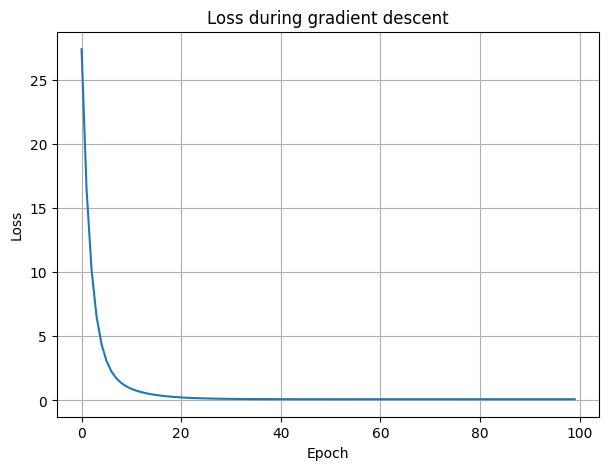

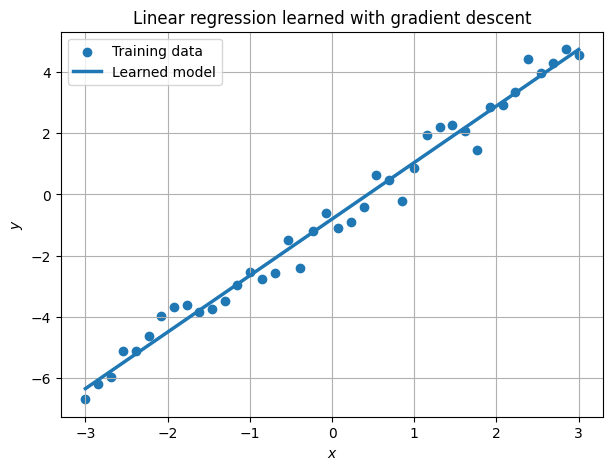

In [13]:
history_array = np.array(history)

plt.plot(history_array[:, 0], history_array[:, 3])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during gradient descent")
plt.show()

plt.scatter(x_train, y_train, label="Training data")
plt.plot(x_train, w_gd*x_train + b_gd, linewidth=2.5, label="Learned model")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Linear regression learned with gradient descent")
plt.legend()
plt.show()

### Activity 10 — Learning-rate experiment

Run the training loop with:

$$
\eta\in\{0.001,\;0.02,\;0.08,\;0.3,\;1.0\}.
$$

For each value, record:

- final loss;
- whether convergence is slow, fast, oscillatory, or unstable;
- the learned $w$ and $b$.

Then answer:

1. What happens when the learning rate is too small?
2. What happens when it is too large?
3. Is a lower learning rate always better?

In [14]:
# Complete and run this experiment
learning_rates = [0.001, 0.02, 0.08, 0.3, 1.0]
results = []

for lr in learning_rates:
    w_test = -2.0
    b_test = 2.0

    for epoch in range(100):
        dw, db = gradients(x_train, y_train, w_test, b_test)
        w_test -= lr * dw
        b_test -= lr * db

    final_loss = mse_half(x_train, y_train, w_test, b_test)
    results.append((lr, w_test, b_test, final_loss))

for result in results:
    print(result)

(0.001, np.float64(-0.9569242440452049), np.float64(1.7327583490976683), np.float64(15.752489412497017))
(0.02, np.float64(1.8453437853471664), np.float64(-0.4346750274888439), np.float64(0.1632698159625045))
(0.08, np.float64(1.8510450631022168), np.float64(-0.8062572091099485), np.float64(0.09393240080629442))
(0.3, np.float64(1.8510450631031243), np.float64(-0.8069286597766813), np.float64(0.0939321753832955))
(1.0, np.float64(-8.073214733170917e+33), np.float64(-5.2888557342233894e+17), np.float64(1.0277879389397718e+68))


# Part 8 — The chain rule and computational graphs

Suppose

$$
z=\mathbf{w}^{T}\mathbf{x}+b,
\qquad
\hat y=\sigma(z),
\qquad
L=L(\hat y,y).
$$

Then

$$
\frac{\partial L}{\partial w_j}
=
\frac{\partial L}{\partial\hat y}
\frac{\partial\hat y}{\partial z}
\frac{\partial z}{\partial w_j}.
$$

Since

$$
\frac{\partial z}{\partial w_j}=x_j,
$$

the local derivatives multiply along the path from $w_j$ to $L$.

This is the central idea of backpropagation.

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# One logistic-regression example
x_log = np.array([1.5, -0.5])
w_log = np.array([0.7, 0.3])
b_log = -0.1
y_log = 1.0

z = w_log @ x_log + b_log
y_hat = sigmoid(z)

# Binary cross-entropy derivative simplifies to y_hat - y
dL_dz = y_hat - y_log
dL_dw = dL_dz * x_log
dL_db = dL_dz

print("z:", z)
print("Predicted probability:", y_hat)
print("dL/dz:", dL_dz)
print("dL/dw:", dL_dw)
print("dL/db:", dL_db)

z: 0.7999999999999998
Predicted probability: 0.6899744811276125
dL/dz: -0.3100255188723875
dL/dw: [-0.465  0.155]
dL/db: -0.3100255188723875


### Activity 11 — Manual backpropagation

Using the previous values, compute by hand:

1. $z$
2. $\hat y=\sigma(z)$
3. $\partial L/\partial z=\hat y-y$
4. $\partial L/\partial w_1$
5. $\partial L/\partial w_2$
6. $\partial L/\partial b$

Then compare your values with the code output.

# Part 9 — Jacobians

For a vector-valued function

$$
\mathbf{f}:\mathbb{R}^{n}\rightarrow\mathbb{R}^{m},
$$

the derivative is the Jacobian:

$$
J_{\mathbf{f}}(\mathbf{x})
=
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1}
&
\cdots
&
\frac{\partial f_1}{\partial x_n}
\\
\vdots
&
\ddots
&
\vdots
\\
\frac{\partial f_m}{\partial x_1}
&
\cdots
&
\frac{\partial f_m}{\partial x_n}
\end{bmatrix}.
$$

For a linear transformation

$$
\mathbf{z}=W\mathbf{x}+\mathbf{b},
$$

the Jacobian with respect to \(\mathbf{x}\) is simply

$$
\frac{\partial\mathbf{z}}{\partial\mathbf{x}}=W.
$$

In [ ]:
W = np.array([
    [2.0, -1.0],
    [0.5,  3.0],
    [-2.0, 1.0],
])

x_jac = np.array([1.0, 2.0])
b_jac = np.array([0.2, -0.3, 1.0])

z_jac = W @ x_jac + b_jac

print("Output z:")
print(z_jac)
print("\nJacobian dz/dx:")
print(W)

### Activity 12 — Read a Jacobian

For the matrix above:

1. What is $\partial z_2/\partial x_1$?
2. What is $\partial z_1/\partial x_2$?
3. Which output is most sensitive to $x_2$?
4. What are the input and output dimensions?

<details>
<summary><strong>Suggested answers</strong></summary>

1. $0.5$
2. $-1$
3. $z_2$, because the largest absolute coefficient in the second column is $3$
4. Input dimension $2$, output dimension $3$

</details>

# Part 10 — Hessians and curvature

For a scalar function $f:\mathbb{R}^{n}\rightarrow\mathbb{R}$, the Hessian is the matrix of second derivatives:

$$
H_f(\mathbf{x})
=
\begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2}
&
\cdots
&
\frac{\partial^2 f}{\partial x_1\partial x_n}
\\
\vdots
&
\ddots
&
\vdots
\\
\frac{\partial^2 f}{\partial x_n\partial x_1}
&
\cdots
&
\frac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}.
$$

For

$$
f(x_1,x_2)=x_1^2+2x_2^2,
$$

$$
H_f=
\begin{bmatrix}
2&0\\
0&4
\end{bmatrix}.
$$

The gradient describes slope. The Hessian describes curvature.

In [ ]:
H = np.array([
    [2.0, 0.0],
    [0.0, 4.0],
])

eigenvalues, eigenvectors = np.linalg.eigh(H)

print("Hessian:")
print(H)
print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

### Activity 13 — Curvature and optimization

1. Why are the level curves elongated rather than circular?
2. In which direction is curvature larger?
3. Why can unequal curvature make gradient descent zigzag?
4. What would the Hessian be for $f(x_1,x_2)=x_1^2+x_2^2$?

<details>
<summary><strong>Suggested answers</strong></summary>

1. The two coordinates have different quadratic coefficients.
2. Along $x_2$, because the second derivative is $4$, compared with $2$ along $x_1$.
3. A learning rate appropriate for the flatter direction may be too aggressive for the steeper direction.
4. $2I$.

</details>

# Part 11 — Integrated classroom challenge

Consider the classifier

$$
s(\mathbf{x})=
\begin{bmatrix}
2\\
-1
\end{bmatrix}^{T}
\mathbf{x}
+3.
$$

Complete the following.

## A. Geometry

1. Write the decision boundary explicitly as $x_2=\cdots$.
2. Give a normal vector.
3. Give a vector parallel to the boundary.
4. Determine the class side of $(0,0)$.
5. Compute the signed distance of $(0,0)$ to the boundary.

## B. Rotation

1. Normalize the weight vector.
2. Construct a perpendicular unit vector.
3. Build an orthogonal basis matrix $Q$.
4. Transform at least four points into $z$-coordinates.
5. Verify that classification depends only on $z_1$.

## C. Calculus

1. Compute $\nabla_{\mathbf{x}}s$.
2. Compute the directional derivative along the boundary.
3. Compute the directional derivative along the normalized weight vector.
4. Explain why these values make geometric sense.

## D. Optimization

Suppose the same linear expression is used as a regression prediction:

$$
\hat y=\mathbf{w}^{T}\mathbf{x}+b.
$$

For $\mathbf{x}=(1,2)$, $y=4$, $\mathbf{w}=(2,-1)$, and $b=3$:

1. Compute $\hat y$.
2. Compute the error.
3. Compute the squared-error loss.
4. Compute $\nabla_{\mathbf{w}}L$.
5. Compute $\partial L/\partial b$.
6. Perform one gradient-descent update using $\eta=0.1$.

In [16]:
# Workspace for the integrated challenge

w_challenge = np.array([2.0, -1.0])
b_challenge = 3.0

# Add your solution below

# Part 12 — Concept map

The main progression is:

$$
\text{slope}
\rightarrow
\text{partial derivatives}
\rightarrow
\text{gradient}
\rightarrow
\text{directional change}
\rightarrow
\text{loss gradient}
\rightarrow
\text{gradient descent}.
$$

For a linear classifier:

$$
\boxed{
\mathbf{w}
=
\nabla_{\mathbf{x}}
\left(
\mathbf{w}^{T}\mathbf{x}+b
\right)
}
$$

and the model can be understood as

$$
\boxed{
\text{project onto }\mathbf{w}
\rightarrow
\text{add }b
\rightarrow
\text{apply a threshold}
}
$$

For learning:

$$
\boxed{
\text{prediction}
\rightarrow
\text{loss}
\rightarrow
\text{gradient}
\rightarrow
\text{parameter update}
}
$$

# Optional extension activities

## Extension 1 — Numerical gradient checking

Implement a numerical approximation of the loss gradient and compare it with the analytical gradient.

$$
\frac{\partial L}{\partial w_j}
\approx
\frac{L(\mathbf{w}+\epsilon\mathbf{e}_j)-L(\mathbf{w}-\epsilon\mathbf{e}_j)}
{2\epsilon}
$$

## Extension 2 — Logistic regression

Replace the linear-regression loss with binary cross-entropy and derive the gradient.

## Extension 3 — Three-dimensional hyperplane

Visualize

$$
w_1x_1+w_2x_2+w_3x_3+b=0
$$

as a plane, and draw the normal vector.

## Extension 4 — Automatic differentiation

Reproduce one of the manual-gradient examples using PyTorch or JAX and compare the results.

## Extension 5 — Mini-project

Create an interactive visualization in which the user changes $w_1$, $w_2$, and $b$, while observing:

- the boundary;
- the normal vector;
- class scores;
- signed distances;
- rotated coordinates.